# Discriminator Window Sweep Results

Plot results from `discriminator_window_sweep.py`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Path to CSV output from discriminator_window_sweep.py
CSV_PATH = "/home/mila/a/aidan.sirbu/track-mjx/results/mlp/260115_141734_544576_23/window_sweep_data.csv"

In [3]:
df = pd.read_csv(CSV_PATH)
df

,window_size,original_mean,original_std,deterministic_mean,deterministic_std,logvar_-0.5_mean,logvar_-0.5_std,logvar_-1_mean,logvar_-1_std,logvar_-2_mean,logvar_-2_std,logvar_-3_mean,logvar_-3_std,logvar_-4_mean,logvar_-4_std,logvar_0_mean,logvar_0_std,predicted_logvar_mean,predicted_logvar_std
0,10,0.999943,0.000141,0.597904,0.004561,0.727485,0.004812,0.668852,0.003247,0.610570,0.004357,0.577989,0.004015,0.601806,0.004123,0.804573,0.003730,0.700392,0.004678
1,12,0.999994,0.000029,0.603283,0.003657,0.739327,0.004272,0.670685,0.004923,0.622878,0.004096,0.578006,0.003353,0.604381,0.003920,0.822595,0.003659,0.726795,0.004286
2,15,1.000000,0.000000,0.609494,0.005350,0.763158,0.004911,0.684747,0.004649,0.632719,0.004422,0.583958,0.004364,0.611168,0.005399,0.836034,0.004833,0.749375,0.004816
3,16,1.000000,0.000000,0.608070,0.005252,0.759462,0.005380,0.700150,0.004456,0.636290,0.005183,0.594161,0.005225,0.614126,0.005333,0.837476,0.004949,0.741369,0.005346
4,20,0.999876,0.000151,0.614871,0.005124,0.780561,0.005775,0.709484,0.005509,0.637540,0.004799,0.600694,0.005052,0.618562,0.005636,0.848373,0.005372,0.757242,0.005480
5,24,1.000000,0.000000,0.618828,0.005345,0.786016,0.004811,0.721977,0.005857,0.644754,0.006272,0.608389,0.005399,0.620505,0.004713,0.860739,0.004988,0.770919,0.004871
6,30,1.000000,0.000000,0.632567,0.005787,0.798557,0.005634,0.732976,0.005249,0.648289,0.006554,0.617202,0.005519,0.631696,0.004957,0.870409,0.006010,0.781421,0.005228
7,40,1.000000,0.000000,0.648448,0.006745,0.807107,0.006137,0.740766,0.006191,0.670978,0.007658,0.621603,0.006186,0.640605,0.006068,0.863377,0.006314,0.795282,0.005911
8,48,0.999844,0.001011,0.655745,0.006234,0.803714,0.005987,0.758053,0.007377,0.687115,0.006432,0.623077,0.007371,0.654327,0.007341,0.864639,0.008606,0.800637,0.007706
9,60,1.000000,0.000000,0.658795,0.008041,0.816726,0.007878,0.763497,0.009187,0.683884,0.008384,0.634732,0.008284,0.672411,0.008077,0.873378,0.007969,0.800208,0.007568


In [13]:
# Extract dataset names from columns (exclude original and predicted_logvar)
mean_cols = [c for c in df.columns if c.endswith('_mean')]
datasets = [c.replace('_mean', '') for c in mean_cols]
datasets = [d for d in datasets if d not in ('original', 'predicted_logvar')]
print(f"Datasets: {datasets}")

Datasets: ['deterministic', 'logvar_-0.5', 'logvar_-1', 'logvar_-2', 'logvar_-3', 'logvar_-4', 'logvar_0']


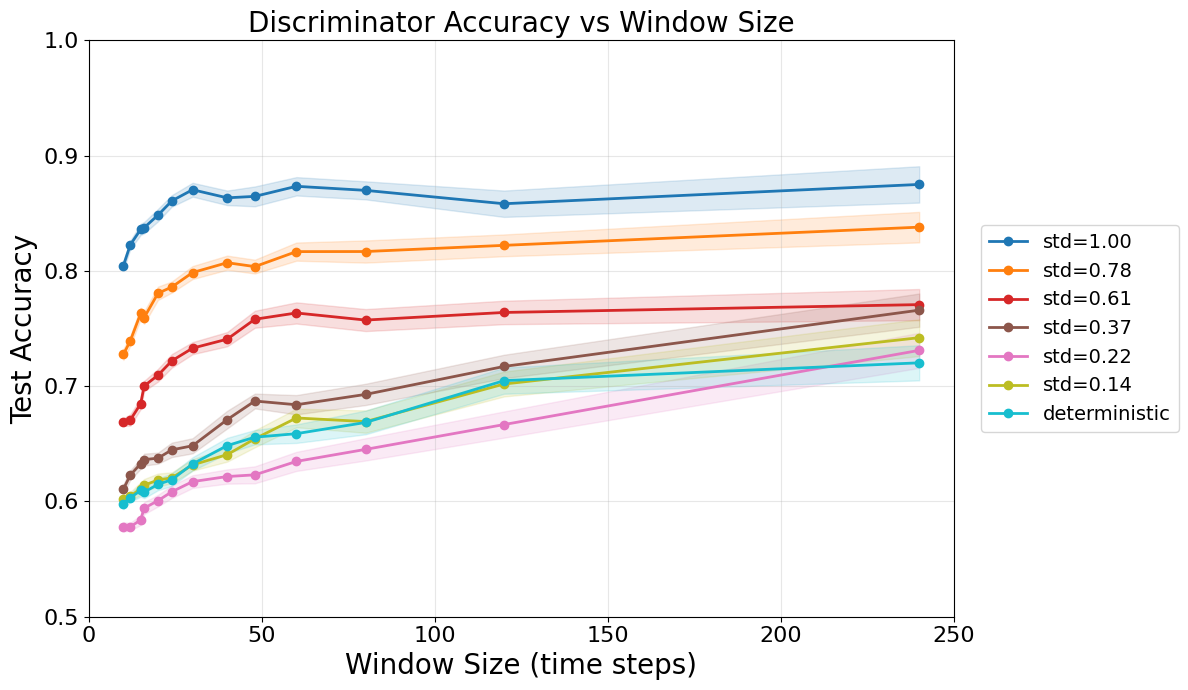

In [20]:
def get_std_from_name(ds_name):
    """Extract std value from dataset name (for sorting)."""
    if ds_name.startswith('logvar_'):
        logvar = float(ds_name.replace('logvar_', ''))
        return np.exp(logvar / 2)
    return None

def get_label(ds_name):
    """Convert dataset name to display label (logvar -> std)."""
    if ds_name == 'deterministic':
        return 'deterministic'
    if ds_name.startswith('logvar_'):
        std = get_std_from_name(ds_name)
        return f'std={std:.2f}'
    return ds_name

# Sort datasets: largest std first, deterministic last
logvar_datasets = [d for d in datasets if d.startswith('logvar_')]
logvar_datasets.sort(key=lambda d: get_std_from_name(d), reverse=True)
sorted_datasets = logvar_datasets + ['deterministic'] if 'deterministic' in datasets else logvar_datasets

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(sorted_datasets)))
window_sizes = df['window_size'].values

for idx, ds in enumerate(sorted_datasets):
    means = df[f'{ds}_mean'].values
    stds = df[f'{ds}_std'].values
    label = get_label(ds)
    
    ax.plot(window_sizes, means, color=colors[idx], linewidth=2,
            marker='o', markersize=6, label=label)
    ax.fill_between(window_sizes, means - stds, means + stds,
                    color=colors[idx], alpha=0.15)

ax.set_xlabel('Window Size (time steps)', fontsize=20)
ax.set_ylabel('Test Accuracy', fontsize=20)
ax.set_title('Discriminator Accuracy vs Window Size', fontsize=20)
ax.set_xlim(0, max(window_sizes) + 10)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=14, loc='center left', bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=16)

plt.tight_layout()
plt.show()

## Compare Multiple Sweeps

Load and compare results from multiple sweep runs (e.g., MLP vs RNN)

In [ ]:
# Optional: compare multiple CSV files
CSV_PATHS = {
    # "MLP": "../results/discriminator_sweep_mlp/window_sweep_data.csv",
    # "RNN": "../results/discriminator_sweep_rnn/window_sweep_data.csv",
}

if CSV_PATHS:
    fig, ax = plt.subplots(figsize=(12, 7))
    linestyles = ['-', '--', ':', '-.']
    
    for run_idx, (run_name, csv_path) in enumerate(CSV_PATHS.items()):
        df_run = pd.read_csv(csv_path)
        mean_cols = [c for c in df_run.columns if c.endswith('_mean')]
        datasets = [c.replace('_mean', '') for c in mean_cols]
        window_sizes = df_run['window_size'].values
        colors = plt.cm.tab10(np.linspace(0, 1, len(datasets)))
        
        for idx, ds in enumerate(datasets):
            means = df_run[f'{ds}_mean'].values
            label = f"{ds} ({run_name})" if len(CSV_PATHS) > 1 else ds
            ax.plot(window_sizes, means, color=colors[idx],
                    linestyle=linestyles[run_idx % len(linestyles)],
                    linewidth=2, marker='o', markersize=5, label=label)
    
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random')
    ax.set_xlabel('Window Size', fontsize=12)
    ax.set_ylabel('Test Accuracy', fontsize=12)
    ax.set_title('Comparison of Discriminator Sweeps', fontsize=14)
    ax.legend(fontsize=9, loc='lower right', ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()